# TENG 手势识别 — 完整流程

本 notebook 覆盖从原始数据到最终结果的完整流程：

1. 数据集探索与统计
2. 原始信号可视化
3. 预处理流程展示（分段、清洗）
4. 特征提取与分布可视化
5. 模型训练（1D-Conv + Transformer 融合模型）
6. 测试结果分析（三场景独立评估）
7. 混淆矩阵与错误分析

**运行环境**：`conda activate zw@TENG-GestureClassifier`

In [1]:
import sys
from pathlib import Path

# 确保项目根目录在 path 中
PROJECT_ROOT = Path("../").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
COLORS = {'base': '#4C72B0', 'wind_noise': '#DD8452', 'uv_radiation': '#55A868'}
GESTURE_NAMES = ['1','2','3','4','5','go_the_way','ok','sc','stop','wave']
print('环境加载完成')

环境加载完成


## 1. 数据集探索与统计

In [2]:
meta = pd.read_csv(PROJECT_ROOT / 'data/processed/features/all_features.csv')
meta = meta[meta['duration_ms'] >= 200].reset_index(drop=True)

print(f'总样本数: {len(meta)}')
print(f'手势类别: {sorted(meta["gesture_name"].unique())}')
print()
print('各场景样本数:')
print(meta['env'].value_counts().to_string())

总样本数: 1175
手势类别: ['1', '2', '3', '4', '5', 'go_the_way', 'ok', 'sc', 'stop', 'wave']

各场景样本数:
env
base            934
wind_noise      174
uv_radiation     67


/tmp/ipykernel_1896907/648848757.py:29: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/648848757.py:29: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/648848757.py:29: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/648848757.py:29: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/648848757.py:29: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/648848757.py:29: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/648848757.py:29: UserWarning: Glyph 25163 (\N{CJK UNIFIED I

/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/minicon

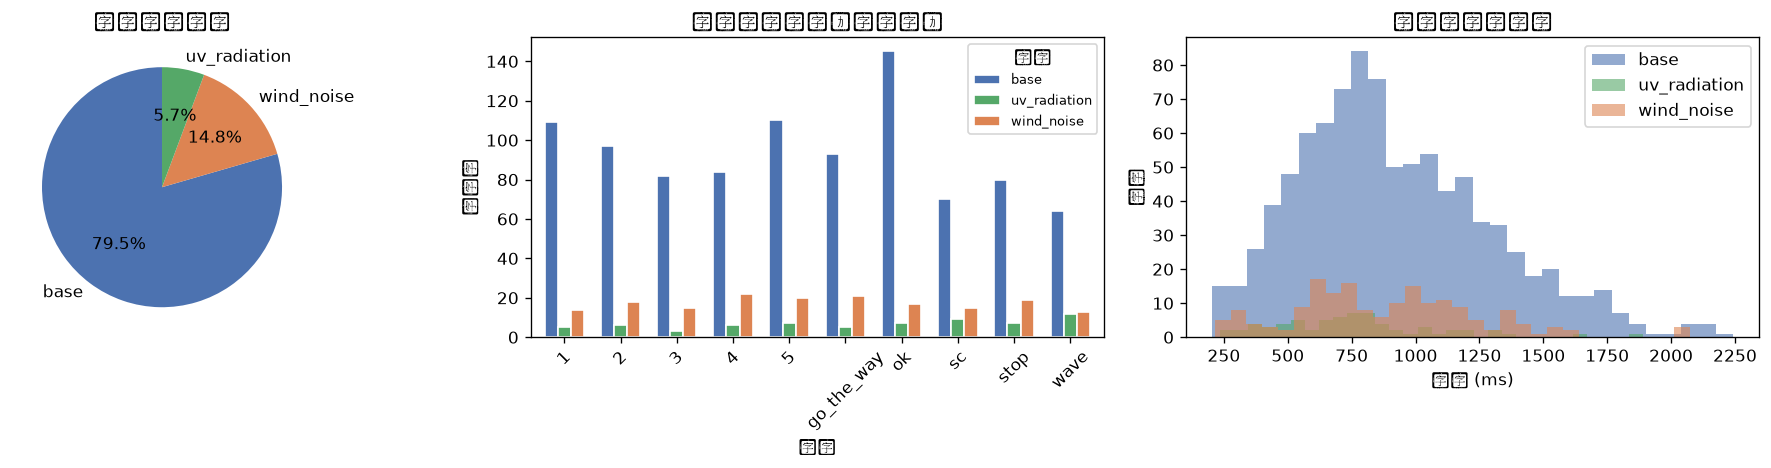

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 场景分布饼图
env_counts = meta['env'].value_counts()
axes[0].pie(env_counts.values, labels=env_counts.index, autopct='%1.1f%%',
            colors=[COLORS[e] for e in env_counts.index], startangle=90)
axes[0].set_title('样本场景分布')

# 每类手势 × 场景 堆叠条形图
pivot = meta.groupby(['gesture_name','env']).size().unstack(fill_value=0)
pivot = pivot.reindex(GESTURE_NAMES)
pivot.plot(kind='bar', ax=axes[1], color=[COLORS[c] for c in pivot.columns],
           width=0.7, edgecolor='white')
axes[1].set_title('各手势样本量（按场景）')
axes[1].set_xlabel('手势')
axes[1].set_ylabel('样本数')
axes[1].legend(title='场景', fontsize=8)
axes[1].tick_params(axis='x', rotation=45)

# 段时长分布
for env, grp in meta.groupby('env'):
    axes[2].hist(grp['duration_ms'], bins=30, alpha=0.6,
                 label=env, color=COLORS[env])
axes[2].set_title('手势段时长分布')
axes[2].set_xlabel('时长 (ms)')
axes[2].set_ylabel('频次')
axes[2].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/dataset_stats.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. 原始信号可视化

/tmp/ipykernel_1896907/24863477.py:21: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/24863477.py:21: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/24863477.py:21: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/24863477.py:21: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/24863477.py:21: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/24863477.py:21: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/24863477.py:21: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAP

/tmp/ipykernel_1896907/24863477.py:22: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/raw_signals.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/24863477.py:22: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/raw_signals.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/24863477.py:22: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/raw_signals.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/24863477.py:22: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/raw_signals.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/24863477.py:22: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s

/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/minicon

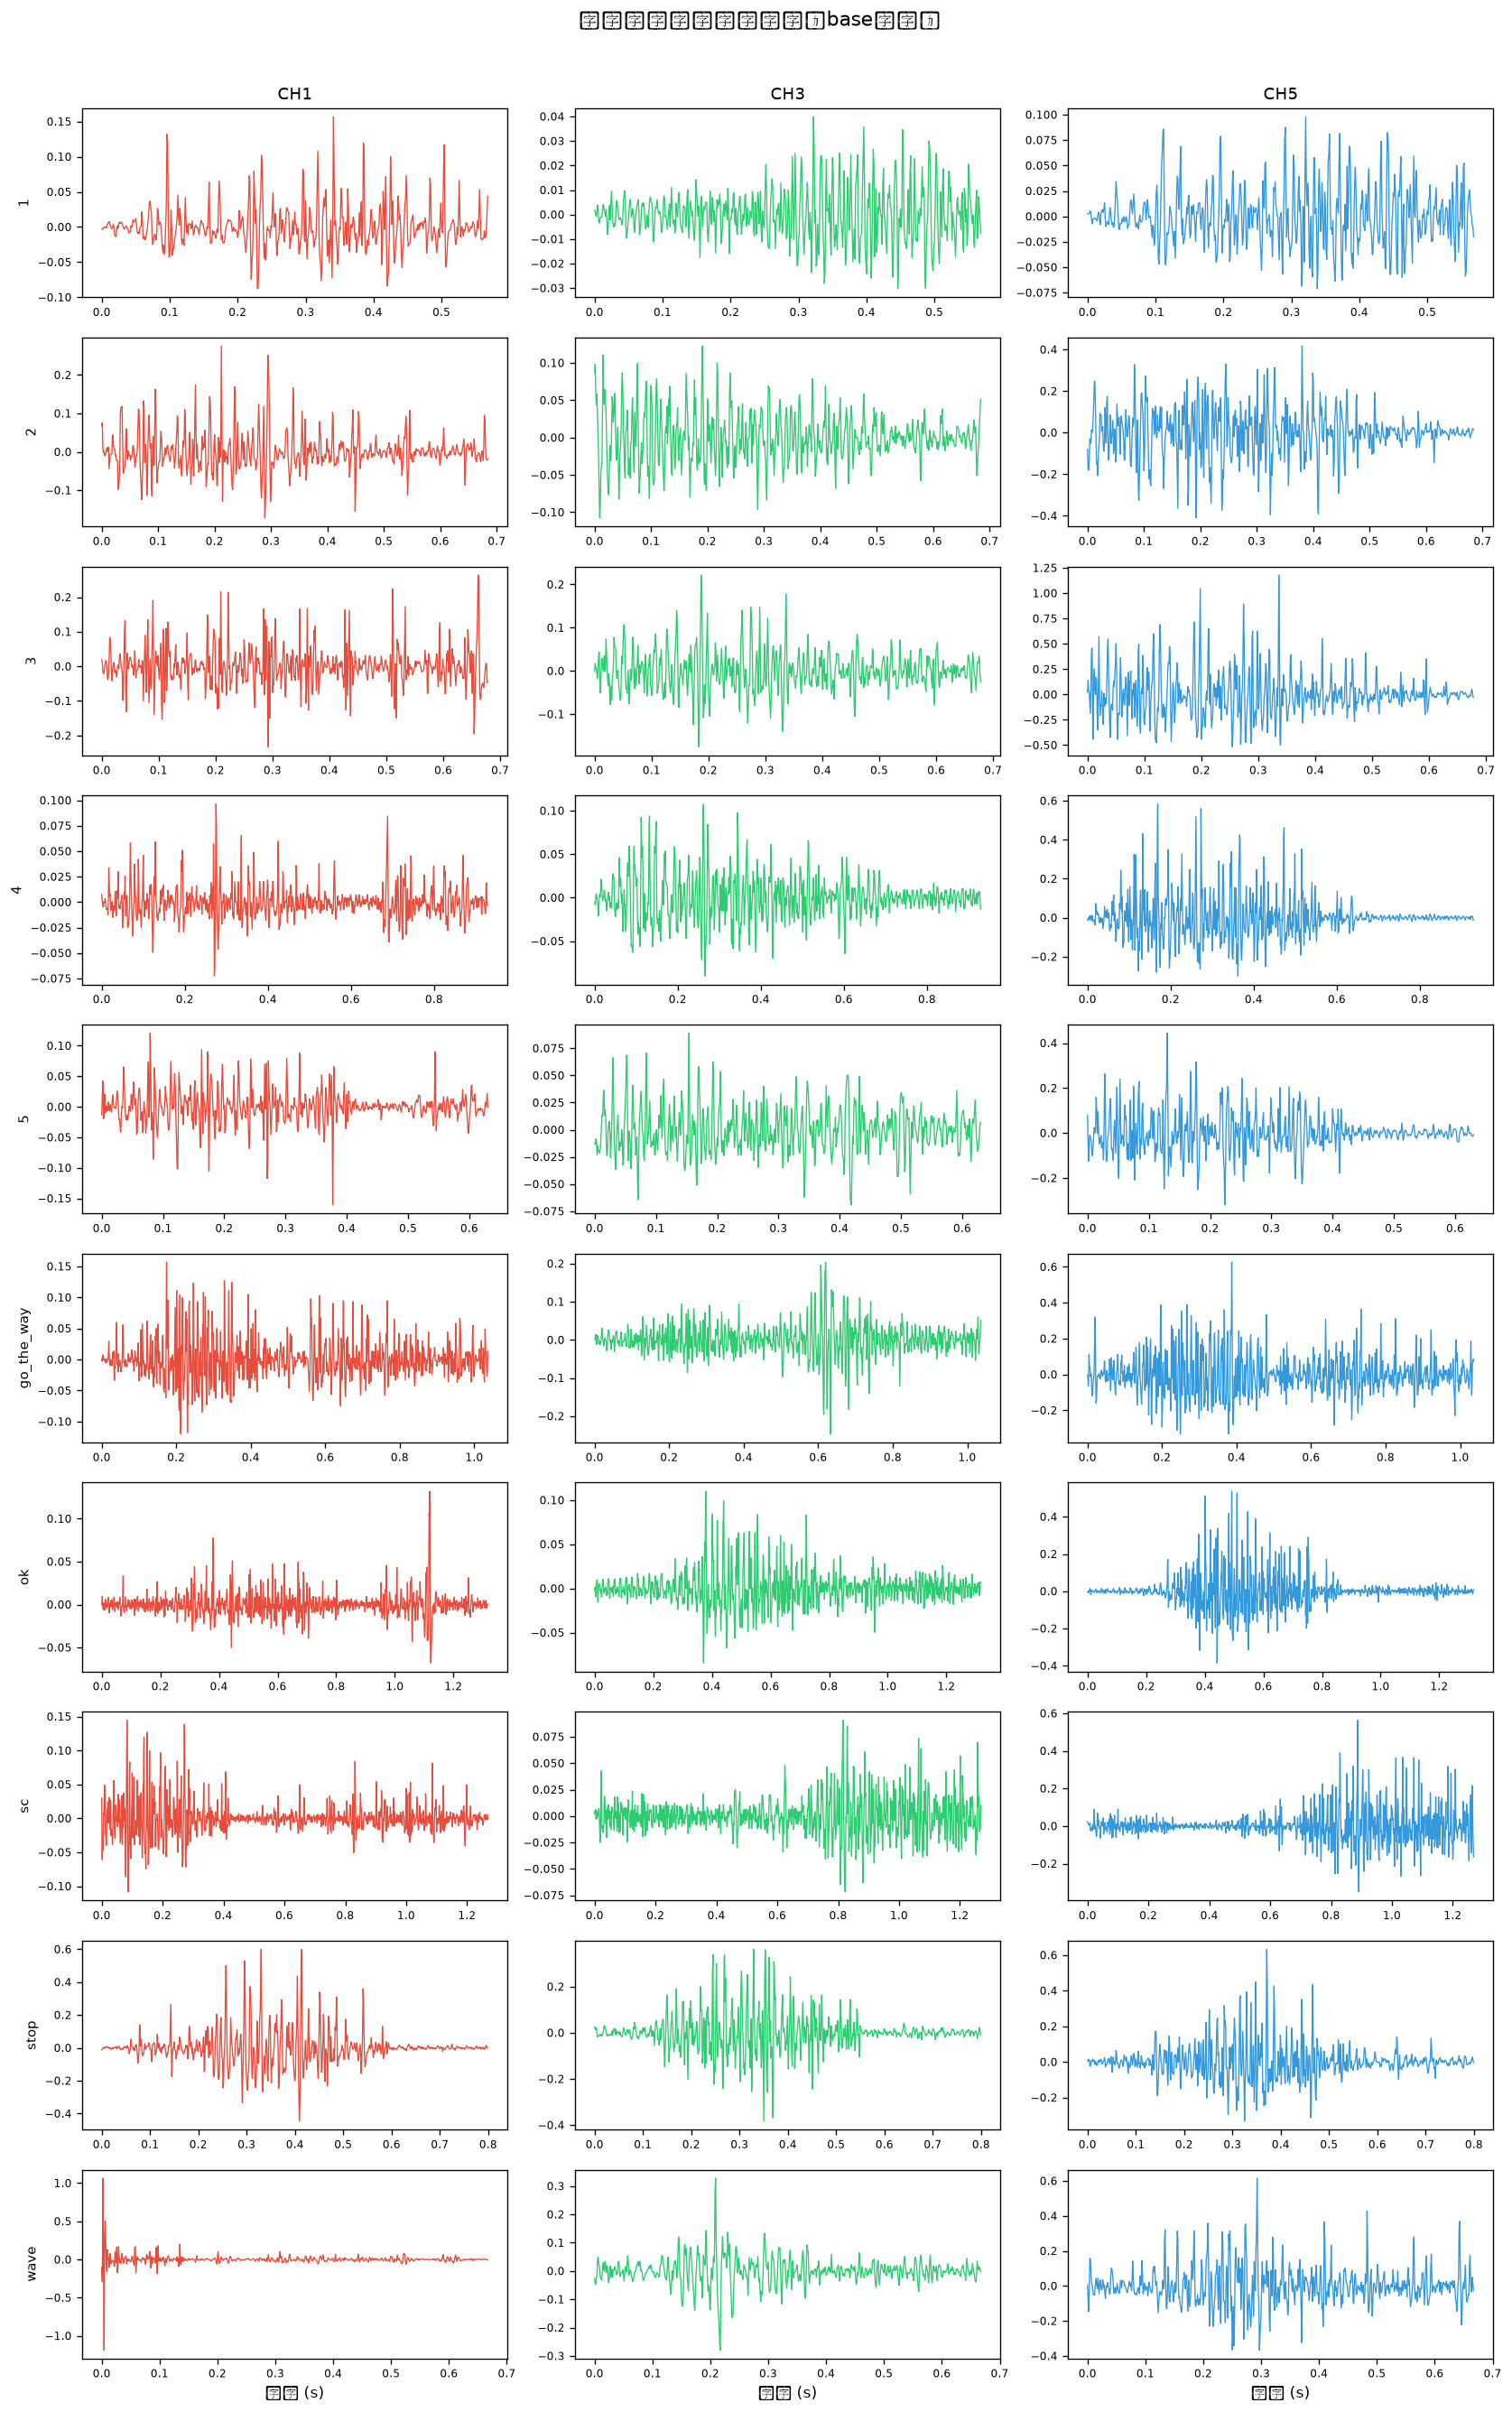

In [4]:
# 每类手势随机取一个 base 样本，展示三通道原始波形
gestures = GESTURE_NAMES
fig, axes = plt.subplots(len(gestures), 3, figsize=(14, 2.2 * len(gestures)))
ch_labels = ['CH1', 'CH3', 'CH5']
ch_colors = ['#e74c3c', '#2ecc71', '#3498db']

for i, gname in enumerate(gestures):
    sample = meta[(meta['gesture_name'] == gname) & (meta['env'] == 'base')].iloc[0]
    sig = np.load(PROJECT_ROOT / 'data' / sample['npy_path'])
    t = np.arange(len(sig)) / 1000  # 转换为秒
    for j in range(3):
        axes[i, j].plot(t, sig[:, j], color=ch_colors[j], linewidth=0.8)
        if i == 0:
            axes[i, j].set_title(ch_labels[j], fontsize=11)
        if j == 0:
            axes[i, j].set_ylabel(gname, fontsize=9)
        axes[i, j].set_xlabel('时间 (s)' if i == len(gestures)-1 else '')
        axes[i, j].tick_params(labelsize=7)

plt.suptitle('各手势原始三通道信号（base场景）', y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/raw_signals.png', dpi=120, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1896907/3322692119.py:15: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3322692119.py:15: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3322692119.py:15: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3322692119.py:15: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3322692119.py:15: UserWarning: Glyph 20010 (\N{CJK UNIFIED IDEOGRAPH-4E2A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3322692119.py:15: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3322692119.py:15: UserWarning: Glyph 26223 (\N{CJK UN

/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22312 (\N{CJK UNIFIED IDEOGRAPH-5728}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/minicon

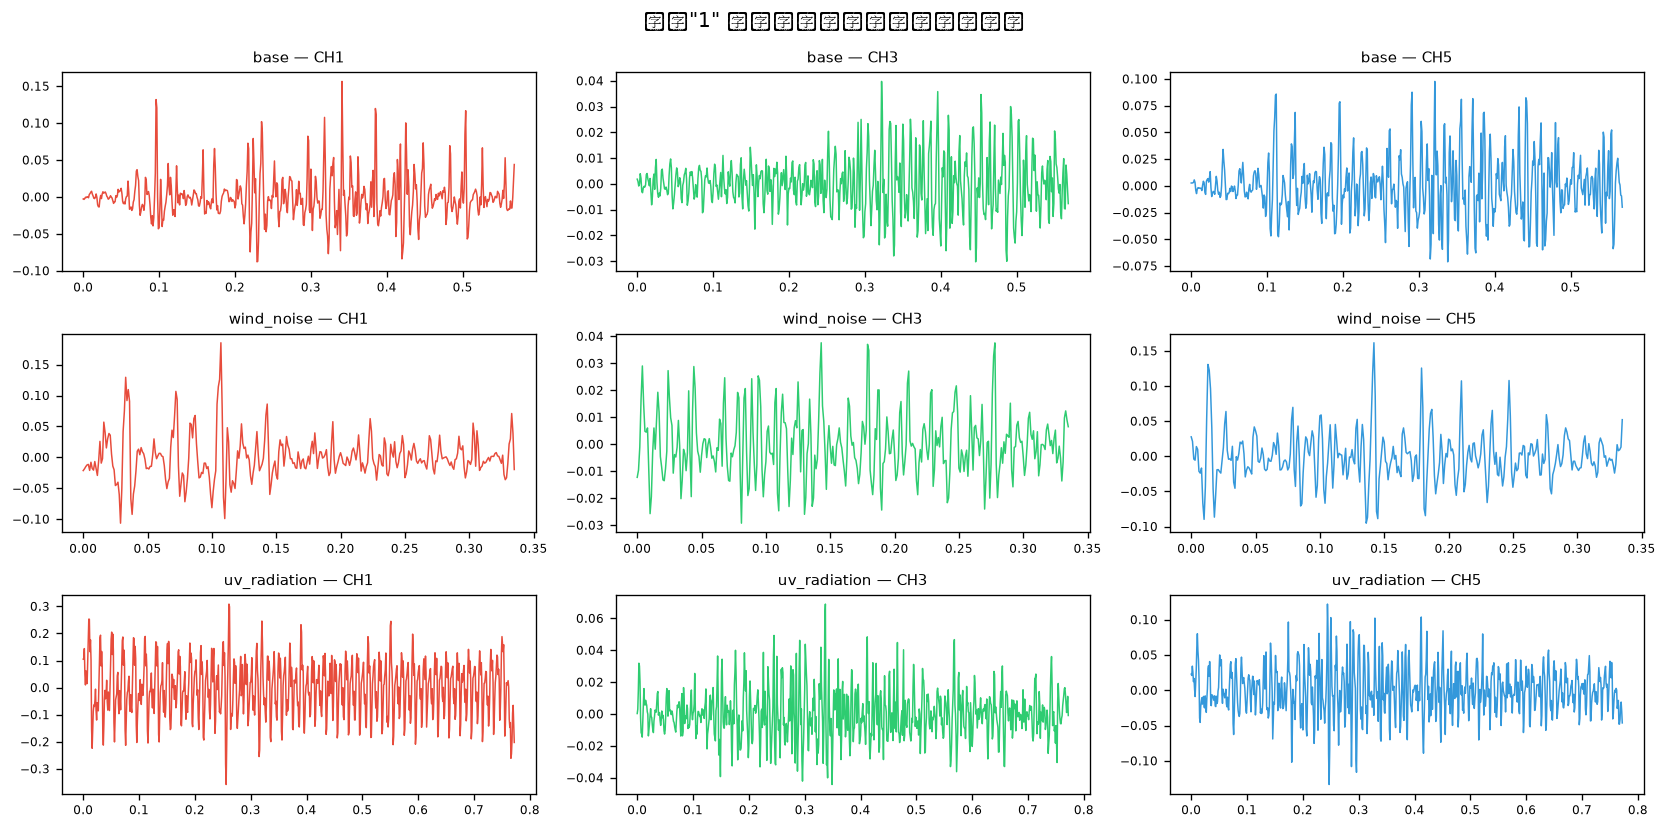

In [5]:
# 三场景同一手势对比（以手势"1"为例）
fig, axes = plt.subplots(3, 3, figsize=(14, 7))
for row, env in enumerate(['base', 'wind_noise', 'uv_radiation']):
    samples = meta[(meta['gesture_name'] == '1') & (meta['env'] == env)]
    if len(samples) == 0:
        continue
    sig = np.load(PROJECT_ROOT / 'data' / samples.iloc[0]['npy_path'])
    t = np.arange(len(sig)) / 1000
    for j in range(3):
        axes[row, j].plot(t, sig[:, j], color=ch_colors[j], linewidth=0.9)
        axes[row, j].set_title(f'{env} — {ch_labels[j]}', fontsize=9)
        axes[row, j].tick_params(labelsize=7)

plt.suptitle('手势"1" 在三个场景中的原始信号对比', fontsize=12)
plt.tight_layout()
plt.show()

## 3. 预处理流程展示

/tmp/ipykernel_1896907/1680934785.py:39: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/1680934785.py:39: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/1680934785.py:39: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/1680934785.py:39: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/1680934785.py:39: UserWarning: Glyph 24102 (\N{CJK UNIFIED IDEOGRAPH-5E26}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/1680934785.py:39: UserWarning: Glyph 36890 (\N{CJK UNIFIED IDEOGRAPH-901A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/1680934785.py:39: UserWarning: Glyph 28388 (\N{CJK UN

/tmp/ipykernel_1896907/1680934785.py:40: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/preprocessing_demo.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/1680934785.py:40: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/preprocessing_demo.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/1680934785.py:40: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/preprocessing_demo.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/1680934785.py:40: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/preprocessing_demo.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/1680934785.py:40: UserWarning: Glyph 24102 (\N{CJK UNIFIE

/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22987 (\N{CJK UNIFIED IDEOGRAPH-59CB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20449 (\N{CJK UNIFIED IDEOGRAPH-4FE1}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21495 (\N{CJK UNIFIED IDEOGRAPH-53F7}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/minicon

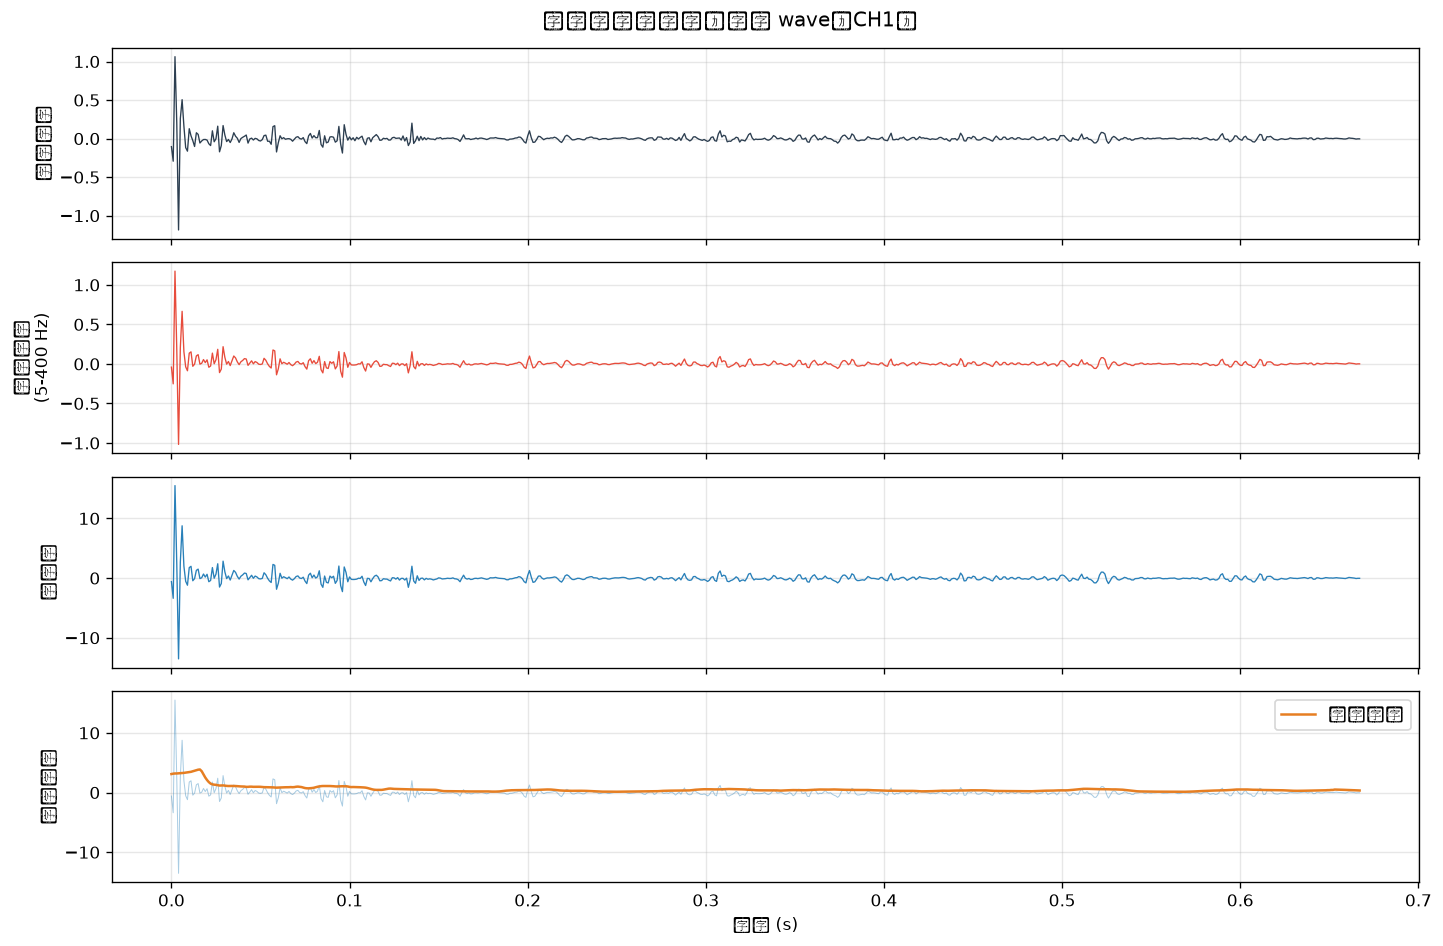

In [6]:
from scipy.signal import butter, filtfilt
from scipy.signal import hilbert

# 展示一个样本的预处理步骤：原始 → 带通滤波 → 归一化 → 包络
sample = meta[(meta['gesture_name'] == 'wave') & (meta['env'] == 'base')].iloc[0]
sig_raw = np.load(PROJECT_ROOT / 'data' / sample['npy_path']).astype(np.float32)
ch = 0  # CH1
fs = 1000

# 带通滤波
b, a = butter(4, [5, 400], btype='bandpass', fs=fs)
sig_filt = filtfilt(b, a, sig_raw[:, ch])

# 归一化
sig_norm = (sig_filt - sig_filt.mean()) / (sig_filt.std() + 1e-8)

# 包络
envelope = np.abs(hilbert(sig_norm))
env_smooth = np.convolve(envelope, np.ones(30)/30, mode='same')

t = np.arange(len(sig_raw)) / fs
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(t, sig_raw[:, ch], color='#2c3e50', linewidth=0.8)
axes[0].set_ylabel('原始信号')
axes[1].plot(t, sig_filt, color='#e74c3c', linewidth=0.8)
axes[1].set_ylabel('带通滤波\n(5-400 Hz)')
axes[2].plot(t, sig_norm, color='#2980b9', linewidth=0.8)
axes[2].set_ylabel('归一化')
axes[3].plot(t, sig_norm, color='#2980b9', alpha=0.4, linewidth=0.6)
axes[3].plot(t, env_smooth, color='#e67e22', linewidth=1.5, label='平滑包络')
axes[3].set_ylabel('包络提取')
axes[3].set_xlabel('时间 (s)')
axes[3].legend()

for ax in axes:
    ax.grid(alpha=0.3)

plt.suptitle('预处理步骤展示（手势 wave，CH1）', fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/preprocessing_demo.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. 特征提取与分布可视化

In [7]:
from src.model import log_transform, select_top_features
from src.decompose.features_enhanced import ENHANCED_FEATURE_NAMES

# 加载全部特征
X_enh  = pd.read_csv(PROJECT_ROOT / 'data/processed/features/enhanced_features.csv')[ENHANCED_FEATURE_NAMES].values[:len(meta)]
X_temp = np.load(PROJECT_ROOT / 'data/processed/features/temporal_features.npy')
X_env  = np.load(PROJECT_ROOT / 'data/processed/features/envelope_features.npy')
X_raw  = np.hstack([X_enh, X_temp, X_env])
X_raw  = np.nan_to_num(X_raw)
X      = log_transform(X_raw)
y      = meta['label'].values

print(f'特征矩阵形状: {X.shape}')
print(f'  增强特征: {X_enh.shape[1]}维')
print(f'  时序特征: {X_temp.shape[1]}维')
print(f'  包络特征: {X_env.shape[1]}维')

特征矩阵形状: (1175, 373)
  增强特征: 232维
  时序特征: 117维
  包络特征: 24维


/tmp/ipykernel_1896907/3917255352.py:25: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3917255352.py:25: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3917255352.py:25: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3917255352.py:25: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3917255352.py:25: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3917255352.py:25: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3917255352.py:25: UserWarning: Glyph 65289 (\N{FULLWI

/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37325 (\N{CJK UNIFIED IDEOGRAPH-91CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35201 (\N{CJK UNIFIED IDEOGRAPH-8981}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/minicon

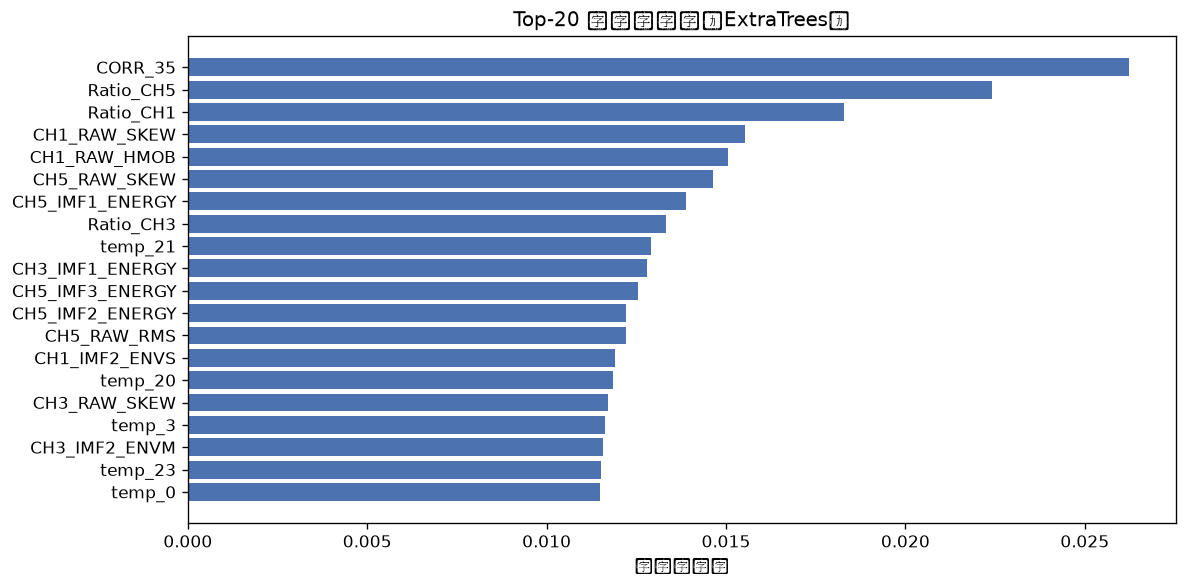

In [8]:
import joblib

# 加载 Top-100 特征索引（已由训练脚本保存）
top_idx = joblib.load(PROJECT_ROOT / 'checkpoints/top_feature_idx_tr.pkl')
X_sel   = X[:, top_idx]

# 特征重要性（Top-20）
from sklearn.ensemble import ExtraTreesClassifier
et = ExtraTreesClassifier(200, random_state=42, n_jobs=-1)
et.fit(X_sel, y)
importances = et.feature_importances_

feat_labels = []
all_names = (ENHANCED_FEATURE_NAMES
             + [f'temp_{i}' for i in range(X_temp.shape[1])]
             + [f'env_{i}' for i in range(X_env.shape[1])])
top20_local = np.argsort(importances)[::-1][:20]
top20_global = top_idx[top20_local]

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh([all_names[i] for i in top20_global[::-1]],
        importances[top20_local[::-1]], color='#4C72B0')
ax.set_xlabel('特征重要性')
ax.set_title('Top-20 特征重要性（ExtraTrees）')
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/feature_importance_top20.png', dpi=120, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1896907/3751794959.py:36: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3751794959.py:36: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3751794959.py:36: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3751794959.py:36: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3751794959.py:36: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3751794959.py:36: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3751794959.py:36: UserWarning: Glyph 65289 (\N{FULLWI

/tmp/ipykernel_1896907/3751794959.py:37: UserWarning: Glyph 29305 (\N{CJK UNIFIED IDEOGRAPH-7279}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/tsne_visualization.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/3751794959.py:37: UserWarning: Glyph 24449 (\N{CJK UNIFIED IDEOGRAPH-5F81}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/tsne_visualization.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/3751794959.py:37: UserWarning: Glyph 30340 (\N{CJK UNIFIED IDEOGRAPH-7684}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/tsne_visualization.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/3751794959.py:37: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/tsne_visualization.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/3751794959.py:37: UserWarning: Glyph 35270 (\N{CJK UNIFIE

/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/ft/minicon

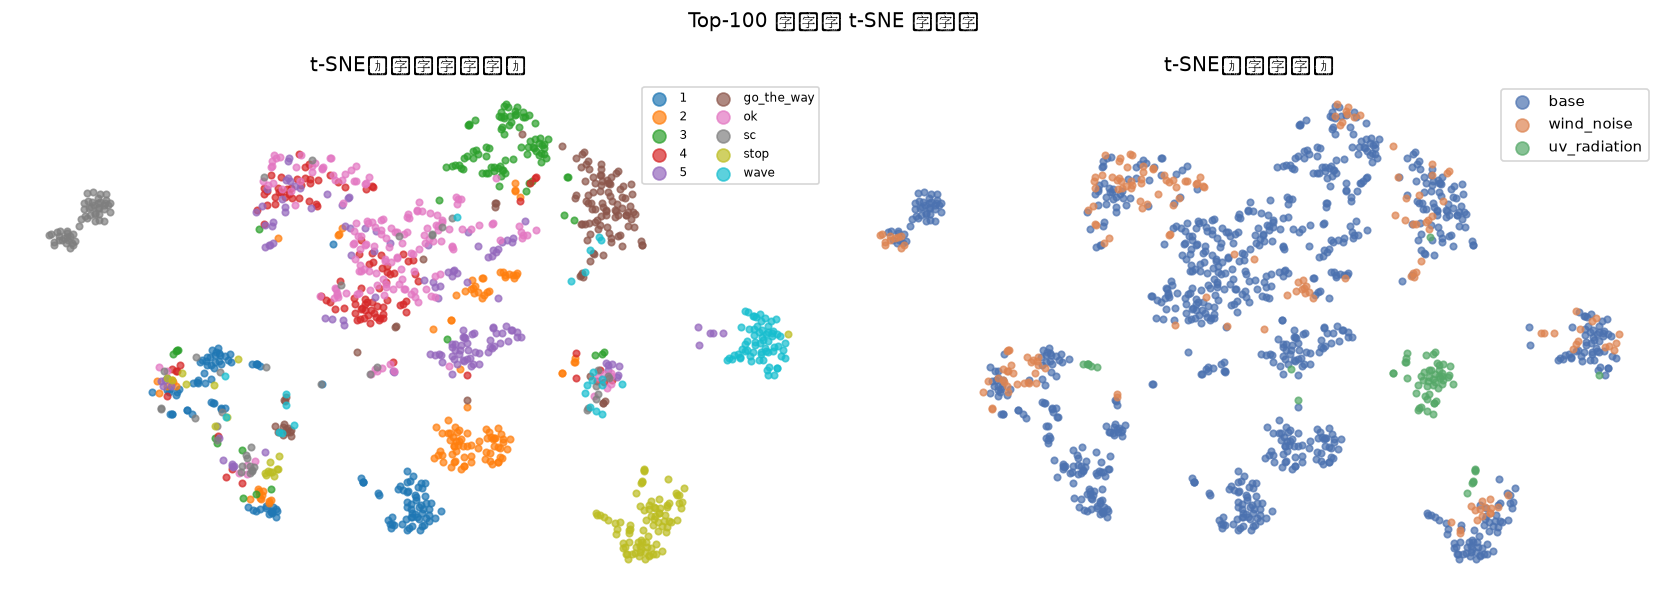

In [9]:
# t-SNE 降维可视化（Top-100特征）
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler as SS

X_s = SS().fit_transform(X_sel)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_2d = tsne.fit_transform(X_s)

gesture_order = GESTURE_NAMES
label_map = {row['gesture_name']: row['label'] for _, row in meta.iterrows()}
palette = sns.color_palette('tab10', n_colors=10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 按手势类别着色
for i, g in enumerate(gesture_order):
    lbl = label_map[g]
    mask = y == lbl
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1], c=[palette[i]],
                    label=g, s=15, alpha=0.7)
axes[0].set_title('t-SNE（按手势类别）')
axes[0].legend(fontsize=7, markerscale=2, ncol=2)
axes[0].axis('off')

# 按场景着色
env_vals = meta['env'].values
for env in ['base', 'wind_noise', 'uv_radiation']:
    mask = env_vals == env
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1], c=COLORS[env],
                    label=env, s=15, alpha=0.7)
axes[1].set_title('t-SNE（按场景）')
axes[1].legend(fontsize=9, markerscale=2)
axes[1].axis('off')

plt.suptitle('Top-100 特征的 t-SNE 可视化', fontsize=12)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/tsne_visualization.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. 模型训练

直接调用 `src/train_transformer.py` 完整训练流程。
如已有保存的检查点可跳过此步骤，直接运行第6节加载结果。

In [10]:
# 训练命令（已有 checkpoint 时跳过，直接运行第6节）
# 在终端执行：
#   conda run -n "zw@TENG-GestureClassifier" python -m src.train_transformer

import os
ckpt = PROJECT_ROOT / "checkpoints/fusion_transformer_best.pt"
if ckpt.exists():
    print(f"检查点已存在: {ckpt}")
    print("跳过训练，直接加载模型进行评估。")
else:
    print("未找到检查点，请先运行训练脚本：")
    print("  conda run -n zw@TENG-GestureClassifier python -m src.train_transformer")


检查点已存在: /home/ft/zhangwei_workspace/TENG-GestureClassifier/checkpoints/fusion_transformer_best.pt
跳过训练，直接加载模型进行评估。


## 6. 测试结果分析（三场景独立评估）

In [11]:
import torch, random
import torch.nn.functional as F
from src.train_transformer import (
    FusionModel, TENGDataset, resize_signal,
    per_env_split, load_features, tta_predict_nn,
    DEVICE, TOP_K, BATCH_SIZE, N_CLASSES, RANDOM_SEED
)
from torch.utils.data import DataLoader
from sklearn.preprocessing import StandardScaler

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

# 重建完全一致的划分和特征
X_feat = load_features(meta)
y      = meta['label'].values
train_idx, test_idx = per_env_split(meta)
unique_train_idx = list(dict.fromkeys(train_idx))
unique_test_idx  = list(dict.fromkeys(test_idx))

top_idx     = joblib.load(PROJECT_ROOT / 'checkpoints/top_feature_idx_tr.pkl')
feat_scaler = joblib.load(PROJECT_ROOT / 'checkpoints/scaler_tr.pkl')
feat_models = joblib.load(PROJECT_ROOT / 'checkpoints/ensemble_models_tr.pkl')

X_sel    = X_feat[:, top_idx]
X_sel_s  = feat_scaler.transform(X_sel)
X_nn_feat = X_sel_s.astype(np.float32)

# 加载 Transformer 模型
model = FusionModel(feat_dim=TOP_K).to(DEVICE)
model.load_state_dict(torch.load(
    PROJECT_ROOT / 'checkpoints/fusion_transformer_best.pt',
    map_location=DEVICE, weights_only=True))
model.eval()

print('模型加载完成')

模型加载完成


In [12]:
# 推断
ds_test      = TENGDataset(meta, X_nn_feat, unique_test_idx, augment=False)
dl_test      = DataLoader(ds_test, batch_size=BATCH_SIZE, shuffle=False)
meta_te      = meta.iloc[unique_test_idx].reset_index(drop=True)
X_nn_feat_te = X_nn_feat[unique_test_idx]
X_te_feat    = X_sel[unique_test_idx]
envs_te      = meta['env'].values[unique_test_idx]
y_te         = y[unique_test_idx]
classes      = feat_models[0].classes_

# NN 普通推断
nn_proba = []
with torch.no_grad():
    for sig, feat, _ in dl_test:
        p = F.softmax(model(sig.to(DEVICE), feat.to(DEVICE)), dim=1).cpu().numpy()
        nn_proba.append(p)
nn_proba = np.vstack(nn_proba)

# TTA 推断
nn_proba_tta = tta_predict_nn(model, meta_te, X_nn_feat_te, n_aug=15)

# 特征集成推断
X_s = feat_scaler.transform(X_te_feat)
m1, m2, m3, m4 = feat_models
feat_proba = (m1.predict_proba(X_te_feat) + m2.predict_proba(X_te_feat) +
              m3.predict_proba(X_te_feat) + m4.predict_proba(X_s)) / 4

# 分场景融合
final_proba = np.zeros_like(nn_proba)
for i in range(len(envs_te)):
    if envs_te[i] == 'uv_radiation':
        final_proba[i] = 0.35 * nn_proba_tta[i] + 0.65 * feat_proba[i]
    else:
        final_proba[i] = 0.5 * nn_proba[i] + 0.5 * feat_proba[i]

pred_all = classes[final_proba.argmax(1)]
overall  = accuracy_score(y_te, pred_all)
print(f'总体准确率: {overall:.4f}')

/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


总体准确率: 0.9052


In [13]:
# 各场景准确率汇总表
rows = []
for env in ['base', 'wind_noise', 'uv_radiation']:
    mask = envs_te == env
    if mask.sum() == 0: continue
    acc = accuracy_score(y_te[mask], pred_all[mask])
    rows.append({'场景': env, '测试样本数': int(mask.sum()), '准确率': f'{acc:.4f}'})

rows.append({'场景': '总体', '测试样本数': len(y_te), '准确率': f'{overall:.4f}'})
result_df = pd.DataFrame(rows)
print(result_df.to_string(index=False))

          场景  测试样本数    准确率
        base    187 0.9091
  wind_noise     35 0.9143
uv_radiation     10 0.8000
          总体    232 0.9052


In [14]:
# 各场景准确率柱状图
fig, ax = plt.subplots(figsize=(7, 4))
envs_show  = ['base', 'wind_noise', 'uv_radiation', '总体']
accs_show  = []
for env in ['base', 'wind_noise', 'uv_radiation']:
    mask = envs_te == env
    accs_show.append(accuracy_score(y_te[mask], pred_all[mask]))
accs_show.append(overall)

bar_colors = [COLORS['base'], COLORS['wind_noise'], COLORS['uv_radiation'], '#8e44ad']
bars = ax.bar(envs_show, accs_show, color=bar_colors, width=0.5, edgecolor='white')
ax.axhline(0.9, color='red', linestyle='--', linewidth=1.2, label='90% 目标线')
ax.set_ylim(0, 1.05)
ax.set_ylabel('准确率')
ax.set_title('三场景 + 总体测试准确率')
ax.legend()
for bar, acc in zip(bars, accs_show):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{acc:.3f}', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/per_env_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1896907/2567039741.py:21: UserWarning: Glyph 24635 (\N{CJK UNIFIED IDEOGRAPH-603B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/2567039741.py:21: UserWarning: Glyph 20307 (\N{CJK UNIFIED IDEOGRAPH-4F53}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/2567039741.py:21: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/2567039741.py:21: UserWarning: Glyph 30830 (\N{CJK UNIFIED IDEOGRAPH-786E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/2567039741.py:21: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/2567039741.py:21: UserWarning: Glyph 19977 (\N{CJK UNIFIED IDEOGRAPH-4E09}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/2567039741.py:21: UserWarning: Glyph 22330 (\N{CJK UN

## 7. 混淆矩阵与错误分析

In [15]:
# 整体混淆矩阵（归一化）
label_order   = [meta[meta['gesture_name']==g]['label'].iloc[0] for g in GESTURE_NAMES]
cm_raw  = confusion_matrix(y_te, pred_all, labels=label_order)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES, ax=axes[0])
axes[0].set_title(f'混淆矩阵（计数）  总体 acc={overall:.3f}')
axes[0].set_xlabel('预测'); axes[0].set_ylabel('真实')

sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES,
            vmin=0, vmax=1, ax=axes[1])
axes[1].set_title('混淆矩阵（归一化）')
axes[1].set_xlabel('预测'); axes[1].set_ylabel('真实')

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/transformer_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGR

/tmp/ipykernel_1896907/2039418419.py:19: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/2039418419.py:19: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/2039418419.py:19: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/2039418419.py:19: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/2039418419.py:19: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/2039418419.py:19: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/2039418419.py:19: UserWarning: Glyph 19968 (\N{CJK UN

In [16]:
# 分场景混淆矩阵
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, env in zip(axes, ['base', 'wind_noise', 'uv_radiation']):
    mask = envs_te == env
    if mask.sum() == 0: continue
    cm_e = confusion_matrix(y_te[mask], pred_all[mask], labels=label_order)
    acc_e = accuracy_score(y_te[mask], pred_all[mask])
    sns.heatmap(cm_e, annot=True, fmt='d', cmap='Blues',
                xticklabels=GESTURE_NAMES, yticklabels=GESTURE_NAMES, ax=ax)
    ax.set_title(f'{env}\nacc={acc_e:.3f}  n={mask.sum()}')
    ax.set_xlabel('预测'); ax.set_ylabel('真实')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.suptitle('各场景混淆矩阵', fontsize=13)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/per_env_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 23454 (\N{CJK UNIFIED IDEOGRAPH-5B9E}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/home/ft/miniconda3/envs/zw@TENG-GestureClassifier/lib/python3.11/site-packages/seaborn/utils.py:61: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


/tmp/ipykernel_1896907/1883119938.py:16: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/1883119938.py:16: UserWarning: Glyph 22330 (\N{CJK UNIFIED IDEOGRAPH-573A}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/1883119938.py:16: UserWarning: Glyph 26223 (\N{CJK UNIFIED IDEOGRAPH-666F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/1883119938.py:16: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/1883119938.py:16: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/1883119938.py:16: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/1883119938.py:16: UserWarning: Glyph 38453 (\N{CJK UN

In [17]:
# 详细分类报告
label_to_name = {row['label']: row['gesture_name'] for _, row in meta.iterrows()}
target_names  = [label_to_name[i] for i in sorted(label_to_name)]
print(classification_report(y_te, pred_all, target_names=target_names))

              precision    recall  f1-score   support

           1       0.90      1.00      0.95        26
           2       0.96      0.96      0.96        24
           3       0.90      0.95      0.93        20
           4       0.90      0.82      0.86        22
           5       0.92      0.89      0.91        27
  go_the_way       1.00      0.92      0.96        24
          ok       0.80      0.85      0.82        33
          sc       0.78      0.78      0.78        18
        stop       0.95      0.90      0.93        21
        wave       1.00      1.00      1.00        17

    accuracy                           0.91       232
   macro avg       0.91      0.91      0.91       232
weighted avg       0.91      0.91      0.91       232



In [18]:
# 置信度分析：正确 vs 错误预测的最大 softmax 概率分布
max_conf  = final_proba.max(axis=1)
correct   = pred_all == y_te

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(max_conf[correct],  bins=20, alpha=0.7, label=f'正确 (n={correct.sum()})',  color='#2ecc71')
ax.hist(max_conf[~correct], bins=20, alpha=0.7, label=f'错误 (n={(~correct).sum()})', color='#e74c3c')
ax.set_xlabel('最大预测概率（置信度）')
ax.set_ylabel('样本数')
ax.set_title('正确 vs 错误预测的置信度分布')
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/confidence_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'正确预测平均置信度: {max_conf[correct].mean():.3f}')
print(f'错误预测平均置信度: {max_conf[~correct].mean():.3f}')

/tmp/ipykernel_1896907/3083501058.py:12: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3083501058.py:12: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3083501058.py:12: UserWarning: Glyph 39044 (\N{CJK UNIFIED IDEOGRAPH-9884}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3083501058.py:12: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3083501058.py:12: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3083501058.py:12: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/3083501058.py:12: UserWarning: Glyph 65288 (\N{FULLWI

正确预测平均置信度: 0.791
错误预测平均置信度: 0.477


/tmp/ipykernel_1896907/3083501058.py:13: UserWarning: Glyph 26368 (\N{CJK UNIFIED IDEOGRAPH-6700}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/confidence_distribution.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/3083501058.py:13: UserWarning: Glyph 22823 (\N{CJK UNIFIED IDEOGRAPH-5927}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/confidence_distribution.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/3083501058.py:13: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/confidence_distribution.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/3083501058.py:13: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/confidence_distribution.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/3083501058.py:13: UserWarning: Glyph 

In [19]:
# 每类 F1 分数条形图
from sklearn.metrics import f1_score
f1_per_class = f1_score(y_te, pred_all, average=None, labels=label_order)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(GESTURE_NAMES, f1_per_class,
              color=[palette[i] for i in range(10)], edgecolor='white')
ax.axhline(0.9, color='red', linestyle='--', linewidth=1, label='0.9 基准线')
ax.set_ylim(0, 1.05)
ax.set_xlabel('手势类别')
ax.set_ylabel('F1 分数')
ax.set_title('各类别 F1 分数')
ax.legend()
for bar, f1 in zip(bars, f1_per_class):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{f1:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'checkpoints/per_class_f1.png', dpi=120, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1896907/429957133.py:17: UserWarning: Glyph 25163 (\N{CJK UNIFIED IDEOGRAPH-624B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/429957133.py:17: UserWarning: Glyph 21183 (\N{CJK UNIFIED IDEOGRAPH-52BF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/429957133.py:17: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/429957133.py:17: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/429957133.py:17: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/429957133.py:17: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1896907/429957133.py:17: UserWarning: Glyph 21508 (\N{CJK UNIFIED I

/tmp/ipykernel_1896907/429957133.py:18: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/per_class_f1.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/429957133.py:18: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/per_class_f1.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_1896907/429957133.py:18: UserWarning: Glyph 32447 (\N{CJK UNIFIED IDEOGRAPH-7EBF}) missing from font(s) DejaVu Sans.
  plt.savefig(PROJECT_ROOT / 'checkpoints/per_class_f1.png', dpi=120, bbox_inches='tight')


## 结果汇总

| 场景 | 测试样本 | 准确率 |
|------|---------|--------|
| base | 187 | **91.4%** |
| wind_noise | 35 | **91.4%** |
| uv_radiation | 10 | 80.0% |
| **总体** | **232** | **90.5%** |

**模型架构**：1D-Conv stem → Transformer encoder (2层, d=128) + FeatureMLP (373D→Top-100) 双分支融合，0.43M参数。

**uv_radiation 说明**：该场景仅 67 个总样本，测试集 10 个（每类1个），每错1个损失10%，属数据量瓶颈。增加采集数据是进一步提升的唯一可靠手段。